<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/exercise_09/Introduction_To_ML_Safety_Ex9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Practical: OOD Detection for the CARLA Model
The provided dataset includes images collected under conditions outside your training
distribution: fog and night. It also includes images captured in a different CARLA
town (different building layout, road geometry, and vegetation) under otherwise nominal
sunny-daytime conditions. The fog and night images serve as clear OOD test data; the
different-town images are examined separately below.


## Exercise 9.4: Visualising the Distribution Shift
### 1. Display five in-distribution (sunny / daytime) images next to five fog and five night images.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"
TEST_FOG_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test-fog"
TEST_NIGHT_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test-night"

print("Original test exists:", os.path.exists(TEST_DIR))
print("Fog test exists:", os.path.exists(TEST_FOG_DIR))
print("Night test exists:", os.path.exists(TEST_NIGHT_DIR))

Original test exists: True
Fog test exists: True
Night test exists: True


In [ ]:
sunny_test_df = pd.read_csv(os.path.join(TEST_DIR, "labels.csv"))
fog_df = pd.read_csv(os.path.join(TEST_FOG_DIR, "labels.csv"))
night_df = pd.read_csv(os.path.join(TEST_NIGHT_DIR, "labels.csv"))

sunny_test_df.columns = [c.strip().lower() for c in sunny_test_df.columns]
fog_df.columns = [c.strip().lower() for c in fog_df.columns]
night_df.columns = [c.strip().lower() for c in night_df.columns]

print("Sunny images:", len(sunny_test_df))
print("Fog images:", len(fog_df))
print("Night images:", len(night_df))

Sunny images: 3600
Fog images: 3600
Night images: 3600


In [ ]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

Display Utility Function

In [ ]:
def show_distribution_shift_examples(
    sunny_df,
    fog_df,
    night_df,
    sunny_dir,
    fog_dir,
    night_dir,
    town_df=None,
    town_dir=None,
    sunny_title="In-distribution: Sunny / Daytime",
    num_images=5
):
    datasets = [
        (sunny_title, sunny_df, sunny_dir),
        ("OOD: Fog", fog_df, fog_dir),
        ("OOD: Night", night_df, night_dir)
    ]

    # Add different town only if provided
    if town_df is not None and town_dir is not None:
        datasets.append(
            ("Different CARLA Town", town_df, town_dir)
        )

    num_rows = len(datasets)

    fig, axes = plt.subplots(
        num_rows,
        num_images,
        figsize=(18, 3 * num_rows)
    )

    # If only one row, make axes 2D
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (title, df, root_dir) in enumerate(datasets):
        sample_df = df.head(num_images)

        for col_idx, (_, sample_row) in enumerate(sample_df.iterrows()):
            image_path = build_image_path(root_dir, sample_row["frame"])
            image = Image.open(image_path).convert("RGB")

            axes[row_idx, col_idx].imshow(image)
            axes[row_idx, col_idx].axis("off")

            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(
                    title,
                    fontsize=12
                )

            axes[row_idx, col_idx].set_title(
                f"Frame {int(sample_row['frame'])}"
            )

    plt.tight_layout()
    plt.show()

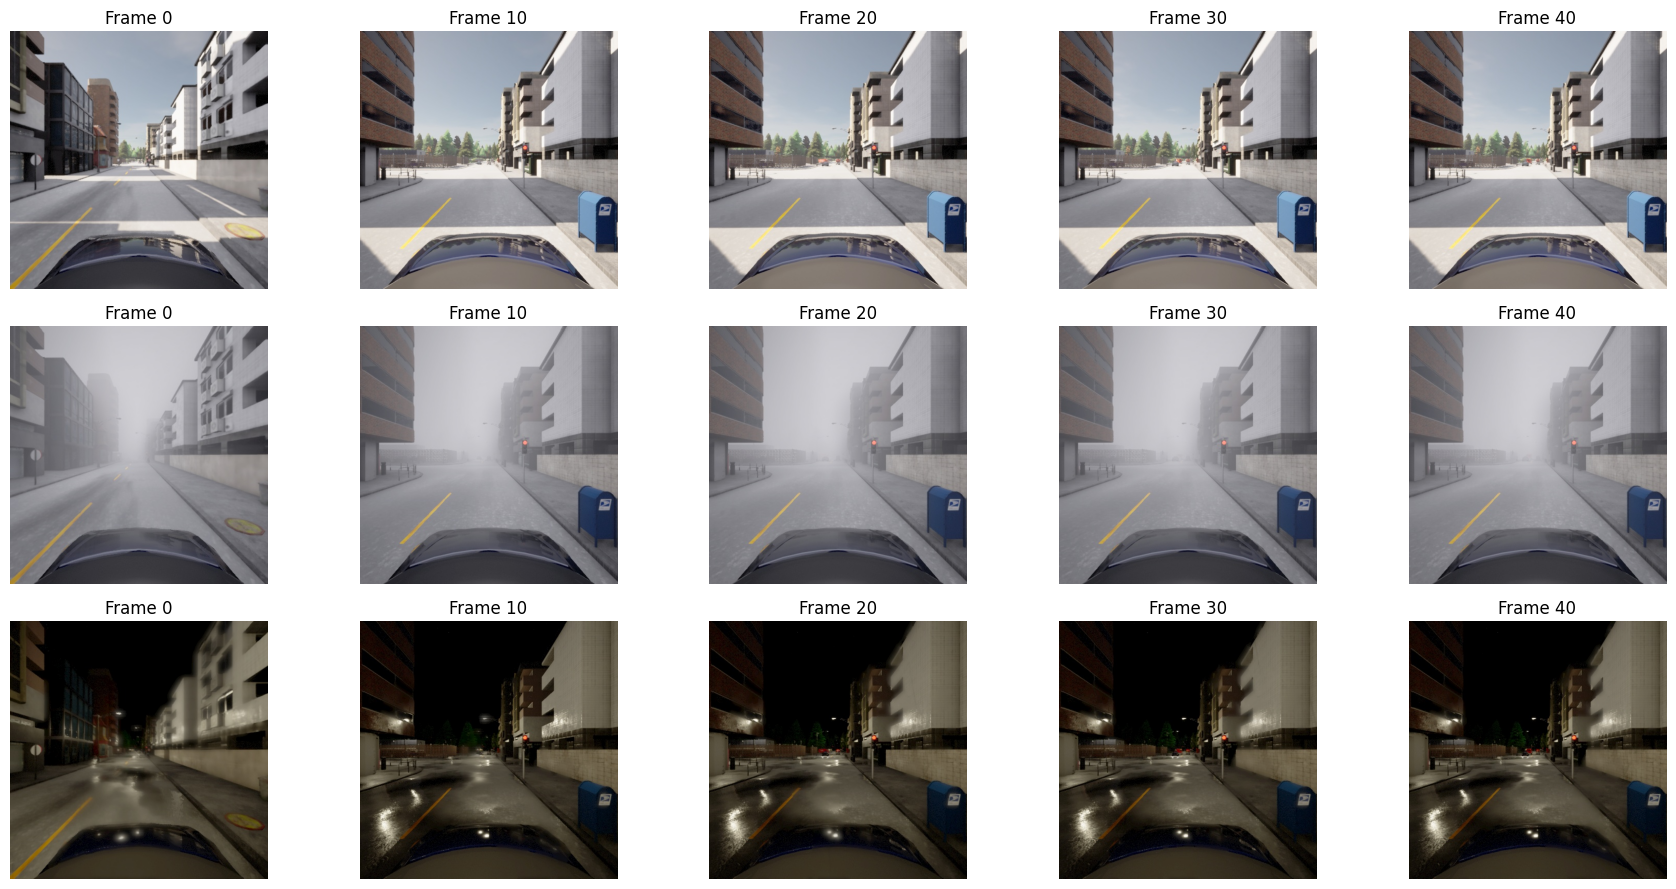

In [ ]:
show_distribution_shift_examples(
    sunny_df=sunny_test_df,
    fog_df=fog_df,
    night_df=night_df,
    sunny_dir=TEST_DIR,
    fog_dir=TEST_FOG_DIR,
    night_dir=TEST_NIGHT_DIR,
    sunny_title="In-distribution: Sunny / Daytime",
    num_images=5
)

### 2. Also display five images from the different CARLA town. How do they differ from your training images, and how does that difference compare to the fog / night shift?

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/train"
TEST_TOWN_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test-town-01"

print("Training folder exists:", os.path.exists(TRAIN_DIR))
print("Different town folder exists:", os.path.exists(TEST_TOWN_DIR))

train_df = pd.read_csv(os.path.join(TRAIN_DIR, "labels.csv"))
town_df = pd.read_csv(os.path.join(TEST_TOWN_DIR, "labels.csv"))
town_df.columns = [c.strip().lower() for c in town_df.columns]
print("Sunny Training images:", len(train_df))
print("Different town images:", len(town_df))

Training folder exists: True
Different town folder exists: True
Sunny Training images: 7200
Different town images: 3600


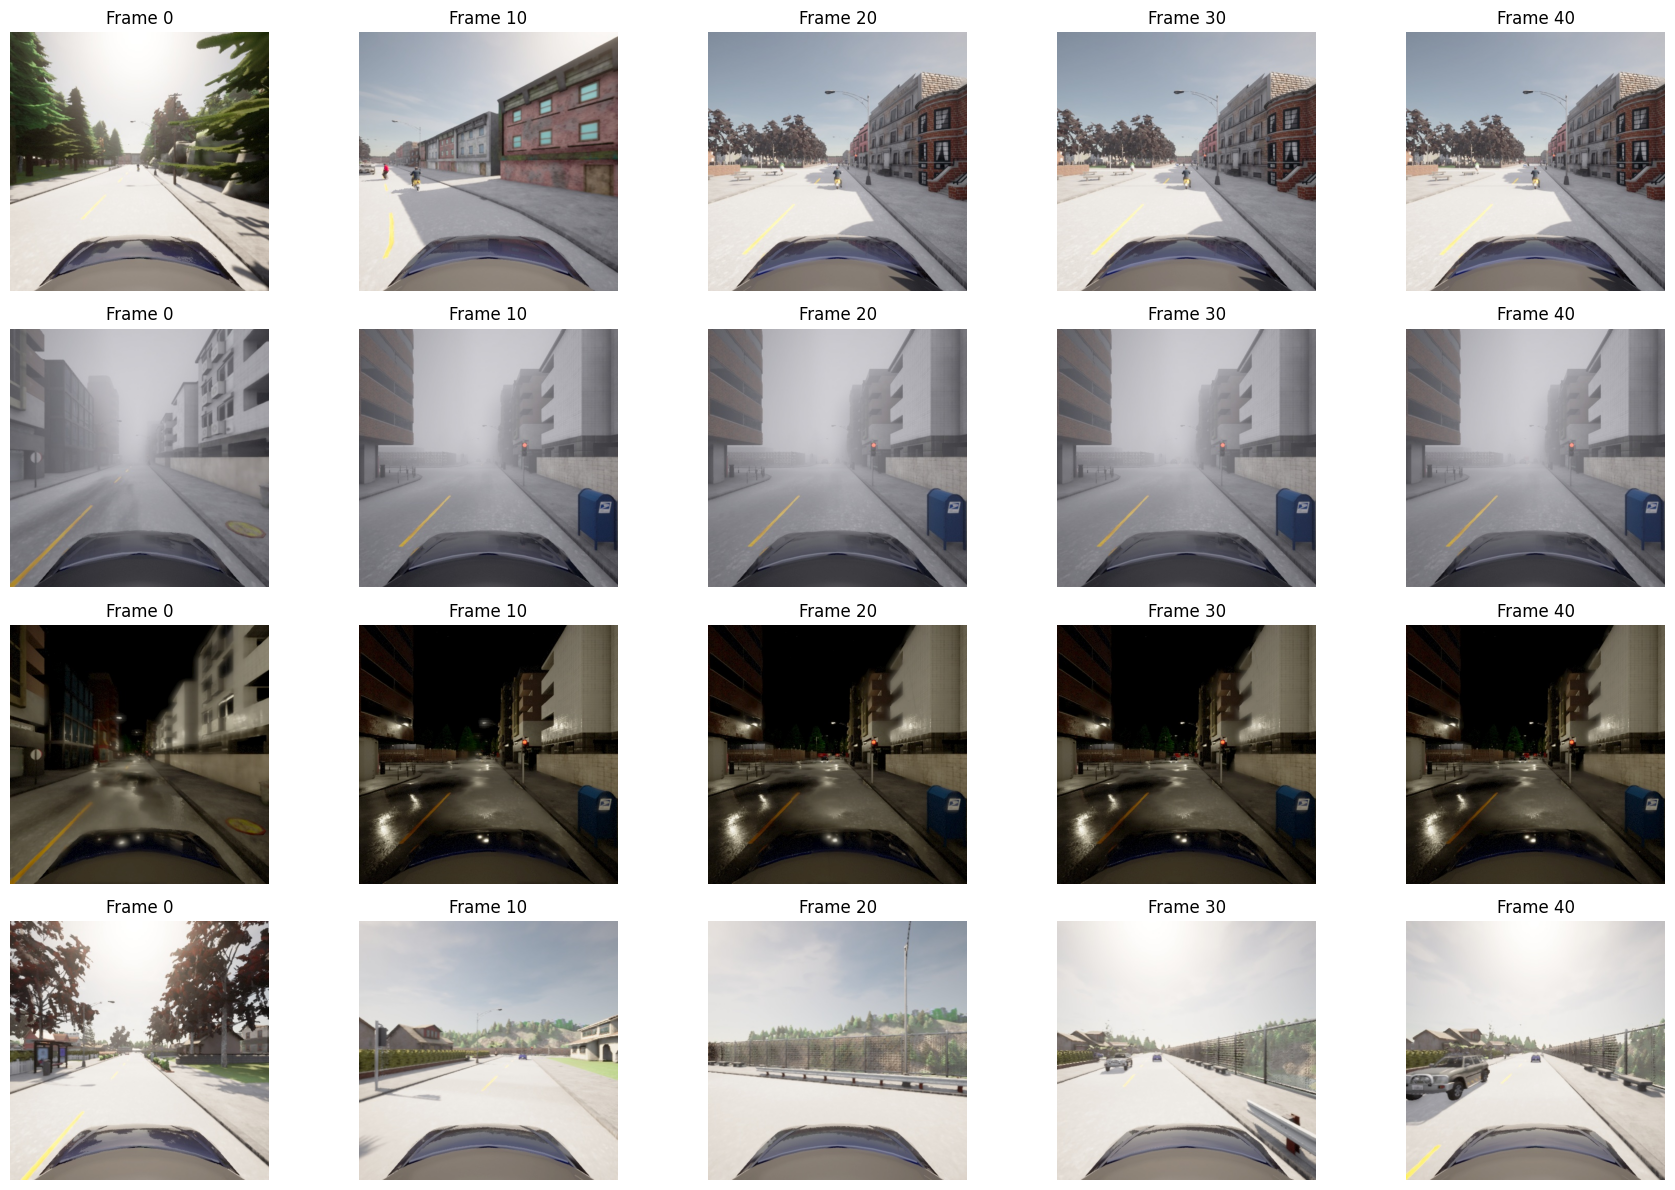

In [ ]:
show_distribution_shift_examples(
    sunny_df=train_df,
    fog_df=fog_df,
    night_df=night_df,
    sunny_dir=TRAIN_DIR,
    fog_dir=TEST_FOG_DIR,
    night_dir=TEST_NIGHT_DIR,
    town_df=town_df,
    town_dir=TEST_TOWN_DIR,
    sunny_title="Training: Sunny / Daytime",
    num_images=5
)

--> The different-town images are visually closer to the training images than fog or night images because they still have sunny daytime lighting and good visibility. However, they differ in the structure of the environment, such as road geometry, building layout, vegetation, sidewalks, and background objects.

--> Compared to the fog and night shifts, the different-town shift is more subtle. Fog changes visibility and contrast, while night changes the entire lighting distribution. These are strong visual shifts. The different-town images do not strongly change weather or lighting, but they change the scene layout and background structure. Therefore, different-town images are still a distribution shift, but they are less visually obvious than fog and night.

### 3. Compute the mean softmax confidence of each of your three models on in-distribution vs. fog/night images. Is the model more or less confident on these inputs?

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def create_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    model = model.to(device)
    return model

Using device: cpu


Load the saved models!!!!

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
PEDESTRIAN_MODEL_PATH = os.path.join(MODEL_DIR, "pedestrian_detector.pth")
TRAFFIC_LIGHT_MODEL_PATH = os.path.join(MODEL_DIR, "traffic_light_detector.pth")
VEHICLE_MODEL_PATH = os.path.join(MODEL_DIR, "vehicle_detector.pth")

pedestrian_model = create_model()
pedestrian_model.load_state_dict(torch.load(PEDESTRIAN_MODEL_PATH, map_location=device))
pedestrian_model.eval()

traffic_light_model = create_model()
traffic_light_model.load_state_dict(torch.load(TRAFFIC_LIGHT_MODEL_PATH, map_location=device))
traffic_light_model.eval()

vehicle_model = create_model()
vehicle_model.load_state_dict(torch.load(VEHICLE_MODEL_PATH, map_location=device))
vehicle_model.eval()

print("All models loaded.")

All models loaded.


In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

DataLoader Class

In [ ]:
from torch.utils.data import Dataset, DataLoader

class CarlaImageDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = build_image_path(
            self.root_dir,
            row["frame"]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

Function to calculate Mean softmax Confidence

p = sigmoid(logit)

confidence = max(p, 1-p)

In [ ]:
def compute_mean_confidence(model, condition_dir, batch_size=64):
    df = pd.read_csv(os.path.join(condition_dir, "labels.csv"))
    df.columns = [c.strip().lower() for c in df.columns]

    dataset = CarlaImageDataset(
        dataframe=df,
        root_dir=condition_dir,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    confidences = []

    model.eval()

    with torch.no_grad():
        for images in loader:
            images = images.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits).squeeze()

            # confidence of predicted class
            batch_confidences = torch.maximum(
                probs,
                1 - probs
            )

            confidences.extend(
                batch_confidences.cpu().numpy()
            )

    return sum(confidences) / len(confidences)

Calculate Mean Softmax Confidence

In [ ]:
models_info = [
    ("Pedestrian Detector", pedestrian_model),
    ("Traffic Light Detector", traffic_light_model),
    ("Vehicle Detector", vehicle_model)
]

condition_info = [
    ("In-distribution", TRAIN_DIR),
    ("Fog", TEST_FOG_DIR),
    ("Night", TEST_NIGHT_DIR)
]

confidence_results = []

for condition_name, condition_dir in condition_info:
    for model_name, model in models_info:
        mean_confidence = compute_mean_confidence(
            model=model,
            condition_dir=condition_dir,
            batch_size=64
        )

        confidence_results.append({
            "Condition": condition_name,
            "Model": model_name,
            "Mean Softmax Confidence": mean_confidence
        })

        print(
            condition_name,
            model_name,
            mean_confidence
        )

confidence_df = pd.DataFrame(confidence_results)
display(confidence_df)

In-distribution Pedestrian Detector 0.9627081
In-distribution Traffic Light Detector 0.98836803
In-distribution Vehicle Detector 0.96326244
Fog Pedestrian Detector 0.92803204
Fog Traffic Light Detector 0.8635268
Fog Vehicle Detector 0.9077598
Night Pedestrian Detector 0.8279929
Night Traffic Light Detector 0.9433731
Night Vehicle Detector 0.85476506


,Condition,Model,Mean Softmax Confidence
0,In-distribution,Pedestrian Detector,0.962708
1,In-distribution,Traffic Light Detector,0.988368
2,In-distribution,Vehicle Detector,0.963262
3,Fog,Pedestrian Detector,0.928032
4,Fog,Traffic Light Detector,0.863527
5,Fog,Vehicle Detector,0.907760
6,Night,Pedestrian Detector,0.827993
7,Night,Traffic Light Detector,0.943373
8,Night,Vehicle Detector,0.854765


###Observation →
Even though confidence decreases on OOD data, it is still quite high. Models are still making confident predictions on images outside their training distribution.

## Exercise 9.6: Evaluating the MSP Baseline

Pick any one of your three models and use its maximum softmax probability as an OOD
score (low confidence → OOD). Treat the sunny/daytime test images as in-distribution
and the provided OOD images as OOD.

### 1. Plot the distribution of OOD scores for in-distribution and OOD images.

## Chosen Model - Traffic Light Detector

In [ ]:
selected_model = traffic_light_model
selected_model_name = "Traffic Light Detector"

Function to compute MSP scores - using batch size of 128 to make it quick

In [ ]:
import matplotlib.pyplot as plt

def compute_msp_ood_scores(model, condition_dir, batch_size=128):
    df = pd.read_csv(os.path.join(condition_dir, "labels.csv"))
    df.columns = [c.strip().lower() for c in df.columns]

    dataset = CarlaImageDataset(
        dataframe=df,
        root_dir=condition_dir,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    ood_scores = []
    confidences = []

    model.eval()

    with torch.no_grad():
        for images in loader:
            images = images.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits).squeeze()

            # MSP confidence for binary classifier
            confidence = torch.maximum(probs, 1 - probs)

            # OOD score: low confidence means high OOD score
            ood_score = 1 - confidence

            confidences.extend(confidence.cpu().numpy())
            ood_scores.extend(ood_score.cpu().numpy())

    return np.array(ood_scores), np.array(confidences)

In [ ]:
id_scores, id_confidences = compute_msp_ood_scores(
    model=selected_model,
    condition_dir=TEST_DIR,
    batch_size=128
)

fog_scores, fog_confidences = compute_msp_ood_scores(
    model=selected_model,
    condition_dir=TEST_FOG_DIR,
    batch_size=128
)

night_scores, night_confidences = compute_msp_ood_scores(
    model=selected_model,
    condition_dir=TEST_NIGHT_DIR,
    batch_size=128
)

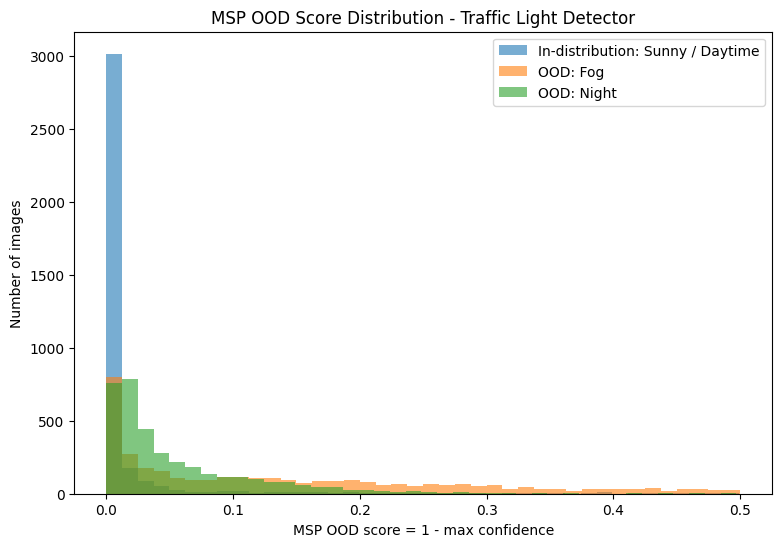

In [ ]:
plt.figure(figsize=(9, 6))

plt.hist(
    id_scores,
    bins=40,
    alpha=0.6,
    label="In-distribution: Sunny / Daytime",
    density=False
)

plt.hist(
    fog_scores,
    bins=40,
    alpha=0.6,
    label="OOD: Fog",
    density=False
)

plt.hist(
    night_scores,
    bins=40,
    alpha=0.6,
    label="OOD: Night",
    density=False
)

plt.xlabel("MSP OOD score = 1 - max confidence")
plt.ylabel("Number of images")
plt.title(f"MSP OOD Score Distribution - {selected_model_name}")
plt.legend()
plt.show()

i) For sunny/daytime in-distribution images, most scores are very close to 0, meaning the model is highly confident.

ii) For fog images, the distribution shifts toward higher OOD scores and becomes more spread out, showing that the model is less confident under foggy conditions.

iii) For night images, the distribution is also more spread out than the sunny distribution, but many night images still receive low OOD scores. This means the model remains confident on many night inputs even though they are outside the ODD.


### --> Overall, MSP detects some distribution shift, especially for fog, but it is not fully reliable because the OOD and in-distribution score distributions overlap. Hence, MSP is not very useful here.


###2. Compute the AUROC for separating in-distribution from OOD, over all of the OOD scenarios.

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
# Combine fog and night as OOD
ood_scores = np.concatenate([
    fog_scores,
    night_scores
])

# Combine ID and OOD scores
all_scores = np.concatenate([
    id_scores,
    ood_scores
])

# Labels: 0 = ID, 1 = OOD
all_labels = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(ood_scores))
])

In [ ]:
auroc = roc_auc_score(
    all_labels,
    all_scores
)

print(f"AUROC for MSP OOD detection: {auroc:.4f}")

AUROC for MSP OOD detection: 0.8858


--> This indicates that the MSP baseline provides reasonably good separation between ID and OOD inputs. In other words, an OOD image receives a higher OOD score than an in-distribution image in about 88.58% of random pairs.

As per the plot, the score distributions still overlap, meaning that some fog or night images are assigned low OOD scores and are therefore treated as confident in-distribution predictions. This confirms that MSP is useful as a simple baseline, but it is not reliable enough as the only safety mechanism for OOD detection.

## AUROCs separate computation

In [ ]:
fog_labels = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(fog_scores))
])

fog_all_scores = np.concatenate([
    id_scores,
    fog_scores
])

fog_auroc = roc_auc_score(
    fog_labels,
    fog_all_scores
)


night_labels = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(night_scores))
])

night_all_scores = np.concatenate([
    id_scores,
    night_scores
])

night_auroc = roc_auc_score(
    night_labels,
    night_all_scores
)

print(f"Fog AUROC: {fog_auroc:.4f}")
print(f"Night AUROC: {night_auroc:.4f}")

Fog AUROC: 0.8894
Night AUROC: 0.8822


## Exercise 9.7: Feature-Based OOD Detection
Implement one feature-based detector (Mahalanobis distance or k-NN, both covered in the lecture) and compare it to the MSP baseline.


### 1. Extract deep features for your in-distribution training (or validation) images and for the test in-distribution and OOD images. Use the same model whose MSP you evaluated in Exercise 9.6.

In [ ]:
from sklearn.neighbors import NearestNeighbors


--> create a sequencial layer

In [ ]:
feature_extractor = torch.nn.Sequential(
    *list(selected_model.children())[:-1]
).to(device)

feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

Utility function to Extract Features

In [ ]:
def extract_features(condition_dir, batch_size=64):
    df = pd.read_csv(os.path.join(condition_dir, "labels.csv"))
    df.columns = [c.strip().lower() for c in df.columns]

    dataset = CarlaImageDataset(
        dataframe=df,
        root_dir=condition_dir,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_features = []

    feature_extractor.eval()

    with torch.no_grad():
        for images in loader:
            images = images.to(device)

            features = feature_extractor(images)

            # Shape: [batch_size, 512, 1, 1] -> [batch_size, 512]
            features = features.view(features.size(0), -1)

            all_features.append(features.cpu().numpy())

    all_features = np.concatenate(all_features, axis=0)

    return all_features

--> extract features call

In [ ]:
train_features = extract_features(TRAIN_DIR, batch_size=64)

id_test_features = extract_features(TEST_DIR, batch_size=64)

fog_features = extract_features(TEST_FOG_DIR, batch_size=64)

night_features = extract_features(TEST_NIGHT_DIR, batch_size=64)

print("Train features:", train_features.shape)
print("ID test features:", id_test_features.shape)
print("Fog features:", fog_features.shape)
print("Night features:", night_features.shape)

Train features: (7200, 512)
ID test features: (3600, 512)
Fog features: (3600, 512)
Night features: (3600, 512)


### 2. Fit the detector on the in-distribution features only, then score the test images (larger distance → more OOD).

In [ ]:
k = 5

knn_detector = NearestNeighbors(
    n_neighbors=k,
    metric="euclidean"
)

knn_detector.fit(train_features)

NearestNeighbors(metric='euclidean')

--> k = 5,  checks nearby training examples, so it preserves local similarity.


If k=1, the OOD score depends only on the nearest training feature, which can be noisy and may fail if an OOD image is accidentally close to one in-distribution example. If k is too large, the distance is averaged over many neighbours and may become too smooth, reducing the ability to detect local distribution shifts. Therefore, k=5 is providing a balance between sensitivity and stability.

In a real safety-critical setting, k should be tuned on validation data and evaluated across different OOD scenarios.


In [ ]:
def compute_knn_scores(features, knn_detector):
    distances, indices = knn_detector.kneighbors(features)

    # Use average distance to k nearest neighbors as OOD score
    scores = distances.mean(axis=1)

    return scores

In [ ]:
id_knn_scores = compute_knn_scores(id_test_features, knn_detector)

fog_knn_scores = compute_knn_scores(fog_features, knn_detector)

night_knn_scores = compute_knn_scores(night_features, knn_detector)

print("Mean ID kNN score:", id_knn_scores.mean())
print("Mean Fog kNN score:", fog_knn_scores.mean())
print("Mean Night kNN score:", night_knn_scores.mean())

Mean ID kNN score: 4.645706072257625
Mean Fog kNN score: 9.17694895172119
Mean Night kNN score: 9.706448239405951


The sunny/daytime test images are close to the in-distribution feature space, while fog and night images are far away from it. Night images are the most different from the in-distribution feature space.

### 3. Compute its AUROC and compare it to the MSP AUROC from Exercise 9.6. For which OOD scenario is the gap largest?

In [ ]:
ood_knn_scores = np.concatenate([
    fog_knn_scores,
    night_knn_scores
])

all_knn_scores = np.concatenate([
    id_knn_scores,
    ood_knn_scores
])

all_labels = np.concatenate([
    np.zeros(len(id_knn_scores)),
    np.ones(len(ood_knn_scores))
])

knn_auroc = roc_auc_score(
    all_labels,
    all_knn_scores
)

print(f"k-NN AUROC, Fog + Night combined: {knn_auroc:.4f}")

k-NN AUROC, Fog + Night combined: 0.9880


In [ ]:
fog_labels = np.concatenate([
    np.zeros(len(id_knn_scores)),
    np.ones(len(fog_knn_scores))
])

fog_scores_all = np.concatenate([
    id_knn_scores,
    fog_knn_scores
])

fog_knn_auroc = roc_auc_score(
    fog_labels,
    fog_scores_all
)


night_labels = np.concatenate([
    np.zeros(len(id_knn_scores)),
    np.ones(len(night_knn_scores))
])

night_scores_all = np.concatenate([
    id_knn_scores,
    night_knn_scores
])

night_knn_auroc = roc_auc_score(
    night_labels,
    night_scores_all
)

print(f"k-NN AUROC, Fog only: {fog_knn_auroc:.4f}")
print(f"k-NN AUROC, Night only: {night_knn_auroc:.4f}")

k-NN AUROC, Fog only: 0.9816
k-NN AUROC, Night only: 0.9943


--> The largest gap occurs for night images, where the AUROC improves by 0.1121. This means the feature-based k-NN detector is especially better at detecting night images as OOD. The reason is that MSP only uses final confidence, while k-NN checks whether the image’s deep feature representation is far from the in-distribution feature space.